# 1. Dataset

In [32]:
mean = [0.7084, 0.5821, 0.5361]
std = [0.0967, 0.1118, 0.1261]
from torchvision import  transforms
data_transforms = {
    'train': transforms.Compose([
        # transforms.RandomResizedCrop(224),
        # transforms.RandomHorizontalFlip(),
        transforms.Resize((+767, 1022)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize((+767, 1022)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((+767, 1022)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
}

mask_transforms = transforms.Compose([
        transforms.Resize((+767, 1022)),
        transforms.ToTensor()
    ])

In [33]:
from torch.utils.data import Dataset
from PIL import Image
import glob

class ISICSegmentationDataset(Dataset):
    def __init__(self,
                image_data_folder_path = "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1-2_Training_Input",
                mask_data_folder_path = "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1_Training_GroundTruth",
                phase = 'train'):
        self.image_data_folder_path = image_data_folder_path
        self.mask_data_folder_path = mask_data_folder_path
        self.phase = phase
        self.img_files = glob.glob(self.image_data_folder_path + "/*.jpg")
        self.mask_imgs = glob.glob(self.mask_data_folder_path + "/*.png")
        self.data_transforms = data_transforms[phase]
        self.mask_transforms = mask_transforms
        self.datalen = len(self.img_files)

    def __getitem__(self, index):
        img = self.img_files[index]
        mask = self.mask_imgs[index]
        img = self.data_transforms(Image.open(img))
        mask = self.mask_transforms(Image.open(mask))

        return img, mask
    
    def __len__(self):
        assert self.datalen == len(self.mask_imgs)
        return self.datalen
    

In [34]:
# import torch
# image_datasets = {x: ISICSegmentationDataset(phase=x) for x in ['train', 'val', 'test']}
# batch_size = {'train':16, 'val':16, 'test':1}
# dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size[x], shuffle=True, num_workers=4)
#               for x in ['train', 'val', 'test']}
# dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val',  'test']}

# device = torch.device("cpu")
# print(device)
# img, mask = image_datasets['train'][3]

# 2. Model

## 2.1. Foundation model

### a. Encoder

In [35]:
import torch.nn as nn
from torchvision.models import resnet


class Encoder(nn.Module):
    """
    An encoder network (image -> feature_dim)
    """
    def __init__(self, arch, feature_dim, cifar_small_image=False):
        super(Encoder, self).__init__()

        resnet_arch = getattr(resnet, arch)
        net = resnet_arch(num_classes=feature_dim)

        self.encoder = []
        for name, module in net.named_children():
            if isinstance(module, nn.Linear):
                self.encoder.append(nn.Flatten(1))
                self.encoder.append(module)
            else:
                if cifar_small_image:
                    # replace first conv from 7x7 to 3x3
                    if name == 'conv1':
                        module = nn.Conv2d(module.in_channels, module.out_channels,
                                           kernel_size=3, stride=1, padding=1, bias=False)
                    # drop first maxpooling
                    if isinstance(module, nn.MaxPool2d):
                        continue
                self.encoder.append(module)
        self.encoder = nn.Sequential(*self.encoder)

    def forward(self, x):
        return self.encoder(x)

### b. Decoder

In [36]:
import os
import math
import torch
import torch.nn as nn


def GroupNorm32(channels):
    return nn.GroupNorm(32, channels)


class TimeEmbedding(nn.Module):
    def __init__(self, n_channels):
        """
        * `n_channels` is the number of dimensions in the embedding
        """
        super().__init__()
        self.n_channels = n_channels
        self.lin1 = nn.Linear(self.n_channels // 4, self.n_channels)
        self.act = nn.SiLU()
        self.lin2 = nn.Linear(self.n_channels, self.n_channels)

    def forward(self, t):
        # Create sinusoidal position embeddings (same as those from the transformer)
        half_dim = self.n_channels // 8
        emb = math.log(10_000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, dtype=torch.float32, device=t.device) * -emb)
        emb = t.float()[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=1)

        # Transform with the MLP
        emb = self.act(self.lin1(emb))
        emb = self.lin2(emb)
        return emb


class LatentEmbedding(nn.Module):
    def __init__(self, n_channels):
        """
        * `n_channels` is the number of dimensions in the embedding
        """
        super().__init__()
        self.n_channels = n_channels

    def forward(self, z, drop_mask):
        """
        * `z` is the latent code
        * `drop_mask`: mask out the condition if drop_mask == 1
        """
        drop_mask = drop_mask[:, None]
        drop_mask = drop_mask.repeat(1, self.n_channels)
        drop_mask = 1 - drop_mask  # need to flip 0 <-> 1
        z = z * drop_mask
        return z


class AttentionBlock(nn.Module):
    def __init__(self, n_channels, d_k):
        """
        * `n_channels` is the number of channels in the input
        * `n_heads` is the number of heads in multi-head attention
        * `d_k` is the number of dimensions in each head
        """
        super().__init__()

        # Default `d_k`
        if d_k is None:
            d_k = n_channels
        n_heads = n_channels // d_k

        self.norm = GroupNorm32(n_channels)
        # Projections for query, key and values
        self.projection = nn.Linear(n_channels, n_heads * d_k * 3)
        # Linear layer for final transformation
        self.output = nn.Linear(n_heads * d_k, n_channels)

        self.scale = 1 / math.sqrt(math.sqrt(d_k))
        self.n_heads = n_heads
        self.d_k = d_k
        if 'LOCAL_RANK' not in os.environ or int(os.environ['LOCAL_RANK']) == 0:
            print(f"{self.n_heads} heads, {self.d_k} channels per head")

    def forward(self, x):
        """
        * `x` has shape `[batch_size, in_channels, height, width]`
        """
        batch_size, n_channels, height, width = x.shape
        # Normalize and rearrange to `[batch_size, seq, n_channels]`
        h = self.norm(x).view(batch_size, n_channels, -1).permute(0, 2, 1)

        # {q, k, v} all have a shape of `[batch_size, seq, n_heads, d_k]`
        qkv = self.projection(h).view(batch_size, -1, self.n_heads, 3 * self.d_k)
        q, k, v = torch.chunk(qkv, 3, dim=-1)

        attn = torch.einsum('bihd,bjhd->bijh', q * self.scale, k * self.scale) # More stable with f16 than dividing afterwards
        attn = attn.softmax(dim=2)
        res = torch.einsum('bijh,bjhd->bihd', attn, v)

        # Reshape to `[batch_size, seq, n_heads * d_k]` and transform to `[batch_size, seq, n_channels]`
        res = res.reshape(batch_size, -1, self.n_heads * self.d_k)
        res = self.output(res)
        res = res.permute(0, 2, 1).view(batch_size, n_channels, height, width)
        return res + x


class Upsample(nn.Module):
    def __init__(self, n_channels, use_conv=True):
        super().__init__()
        self.use_conv = use_conv
        if use_conv:
            self.conv = nn.Conv2d(n_channels, n_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        x = torch.nn.functional.interpolate(x, scale_factor=2, mode="nearest")
        if self.use_conv:
            return self.conv(x)
        else:
            return x


class Downsample(nn.Module):
    def __init__(self, n_channels, use_conv=True):
        super().__init__()
        self.use_conv = use_conv
        if use_conv:
            self.conv = nn.Conv2d(n_channels, n_channels, kernel_size=3, stride=2, padding=1)
        else:
            self.pool = nn.AvgPool2d(2)

    def forward(self, x):
        if self.use_conv:
            return self.conv(x)
        else:
            return self.pool(x)

In [37]:
import torch
from torch import nn


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_channels, z_channels, dropout=0.1, up=False, down=False):
        """
        * `in_channels` is the number of input channels
        * `out_channels` is the number of output channels
        * `time_channels` is the number channels in the time step ($t$) embeddings
        * `z_channels` is the number channels in the latent code derived by the resnet encoder
        * `dropout` is the dropout rate
        """
        super().__init__()
        self.norm1 = GroupNorm32(in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.norm2 = GroupNorm32(out_channels)
        self.act2 = nn.SiLU()
        self.conv2 = nn.Sequential(
            nn.Dropout(dropout),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        )

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

        # Linear layer for embeddings
        self.time_emb = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_channels, 2 * out_channels)
        )
        self.z_emb = nn.Sequential(
            nn.SiLU(),
            nn.Linear(z_channels, 2 * out_channels)
        )

        # BigGAN style: use resblock for up/downsampling
        self.updown = up or down
        if up:
            self.h_upd = Upsample(in_channels, use_conv=False)
            self.x_upd = Upsample(in_channels, use_conv=False)
        elif down:
            self.h_upd = Downsample(in_channels, use_conv=False)
            self.x_upd = Downsample(in_channels, use_conv=False)
        else:
            self.h_upd = self.x_upd = nn.Identity()

    def forward(self, x, t, z):
        """
        * `x` has shape `[batch_size, in_channels, height, width]`
        * `t` has shape `[batch_size, time_channels]`
        * `z` has shape `[batch_size, z_channels]`
        """
        if self.updown:
            h = self.norm2(self.conv1(self.h_upd(self.act1(self.norm1(x)))))
            x = self.x_upd(x)
        else:
            h = self.norm2(self.conv1(self.act1(self.norm1(x))))

        # Adaptive Group Normalization
        t_s, t_b = self.time_emb(t).chunk(2, dim=1)
        z_s, z_b = self.z_emb(z).chunk(2, dim=1)
        h = t_s[:, :, None, None] * h + t_b[:, :, None, None]
        h = z_s[:, :, None, None] * h + z_b[:, :, None, None]

        h = self.conv2(self.act2(h))
        return h + self.shortcut(x)


class ResAttBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_channels, z_channels, has_attn, attn_channels_per_head, dropout):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_channels, z_channels, dropout=dropout)
        if has_attn:
            self.attn = AttentionBlock(out_channels, attn_channels_per_head)
        else:
            self.attn = nn.Identity()

    def forward(self, x, t, z):
        x = self.res(x, t, z)
        x = self.attn(x)
        return x


class MiddleBlock(nn.Module):
    def __init__(self, n_channels, time_channels, z_channels, attn_channels_per_head, dropout):
        super().__init__()
        self.res1 = ResidualBlock(n_channels, n_channels, time_channels, z_channels, dropout=dropout)
        self.attn = AttentionBlock(n_channels, attn_channels_per_head)
        self.res2 = ResidualBlock(n_channels, n_channels, time_channels, z_channels, dropout=dropout)

    def forward(self, x, t, z):
        x = self.res1(x, t, z)
        x = self.attn(x)
        x = self.res2(x, t, z)
        return x


class UpsampleRes(nn.Module):
    def __init__(self, n_channels, time_channels, z_channels, dropout):
        super().__init__()
        self.op = ResidualBlock(n_channels, n_channels, time_channels, z_channels, dropout=dropout, up=True)

    def forward(self, x, t, z):
        return self.op(x, t, z)


class DownsampleRes(nn.Module):
    def __init__(self, n_channels, time_channels, z_channels, dropout):
        super().__init__()
        self.op = ResidualBlock(n_channels, n_channels, time_channels, z_channels, dropout=dropout, down=True)

    def forward(self, x, t, z):
        return self.op(x, t, z)
 

class UNet_decoder(nn.Module):
    def __init__(self, image_shape = [3, 32, 32], n_channels = 128,
                 ch_mults = (1, 2, 2, 2),
                 is_attn = (False, True, False, False),
                 attn_channels_per_head = None,
                 dropout = 0.1,
                 n_blocks = 2,
                 use_res_for_updown = False,
                 z_channels = 128):
        """
        * `image_shape` is the (channel, height, width) size of images.
        * `n_channels` is number of channels in the initial feature map that we transform the image into
        * `ch_mults` is the list of channel numbers at each resolution. The number of channels is `n_channels * ch_mults[i]`
        * `is_attn` is a list of booleans that indicate whether to use attention at each resolution
        * `dropout` is the dropout rate
        * `n_blocks` is the number of `UpDownBlocks` at each resolution
        * `use_res_for_updown` indicates whether to use ResBlocks for up/down sampling (BigGAN-style)
        * `z_channels` is the number channels in the latent code derived by the resnet encoder
        """
        super().__init__()

        n_resolutions = len(ch_mults)

        self.image_proj = nn.Conv2d(image_shape[0], n_channels, kernel_size=3, padding=1)

        # Time embedding layer.
        time_channels = n_channels * 4
        self.time_emb = TimeEmbedding(time_channels)

        # Latent embedding layer.
        self.z_emb = LatentEmbedding(z_channels)

        # Down stages
        down = []
        in_channels = n_channels
        h_channels = [n_channels]
        for i in range(n_resolutions):
            # Number of output channels at this resolution
            out_channels = n_channels * ch_mults[i]
            # `n_blocks` at the same resolution
            down.append(ResAttBlock(in_channels, out_channels, time_channels, z_channels, is_attn[i], attn_channels_per_head, dropout))
            h_channels.append(out_channels)
            for _ in range(n_blocks - 1):
                down.append(ResAttBlock(out_channels, out_channels, time_channels, z_channels, is_attn[i], attn_channels_per_head, dropout))
                h_channels.append(out_channels)
            # Down sample at all resolutions except the last
            if i < n_resolutions - 1:
                if use_res_for_updown:
                    down.append(DownsampleRes(out_channels, time_channels, z_channels, dropout))
                else:
                    down.append(Downsample(out_channels))
                h_channels.append(out_channels)
            in_channels = out_channels
        self.down = nn.ModuleList(down)

        # Middle block
        self.middle = MiddleBlock(out_channels, time_channels, z_channels, attn_channels_per_head, dropout)

        # Up stages
        up = []
        in_channels = out_channels
        for i in reversed(range(n_resolutions)):
            # Number of output channels at this resolution
            out_channels = n_channels * ch_mults[i]
            # `n_blocks + 1` at the same resolution
            for _ in range(n_blocks + 1):
                up.append(ResAttBlock(in_channels + h_channels.pop(), out_channels, time_channels, z_channels, is_attn[i], attn_channels_per_head, dropout))
                in_channels = out_channels
            # Up sample at all resolutions except last
            if i > 0:
                if use_res_for_updown:
                    up.append(UpsampleRes(out_channels, time_channels, z_channels, dropout))
                else:
                    up.append(Upsample(out_channels))
        assert not h_channels
        self.up = nn.ModuleList(up)

        # Final normalization and convolution layer
        self.norm = nn.GroupNorm(8, out_channels)
        self.act = nn.SiLU()
        self.final = nn.Conv2d(out_channels, image_shape[0], kernel_size=3, padding=1)

    def forward(self, x, t, z, drop_mask, ret_activation=False):
        if not ret_activation:
            return self.forward_core(x, t, z, drop_mask)

        activation = {}
        def namedHook(name):
            def hook(module, input, output):
                activation[name] = output
            return hook
        hooks = {}
        no = 0
        for blk in self.up:
            if isinstance(blk, ResAttBlock):
                no += 1
                name = f'out_{no}'
                hooks[name] = blk.register_forward_hook(namedHook(name))

        result = self.forward_core(x, t, z, drop_mask)
        for name in hooks:
            hooks[name].remove()
        return result, activation

    def forward_core(self, x, t, z, drop_mask):
        """
        * `x` has shape `[batch_size, in_channels, height, width]`
        * `t` has shape `[batch_size]`
        * `z` has shape `[batch_size, z_channels]`
        * `drop_mask` has shape `[batch_size]`
        """

        t = self.time_emb(t)
        x = self.image_proj(x)
        z = self.z_emb(z, drop_mask)

        # `h` will store outputs at each resolution for skip connection
        h = [x]

        for m in self.down:
            if isinstance(m, Downsample):
                x = m(x)
            elif isinstance(m, DownsampleRes):
                x = m(x, t, z)
            else:
                x = m(x, t, z).contiguous()
            h.append(x)

        x = self.middle(x, t, z).contiguous()

        for m in self.up:
            if isinstance(m, Upsample):
                x = m(x)
            elif isinstance(m, UpsampleRes):
                x = m(x, t, z)
            else:
                # Get the skip connection from first half of U-Net and concatenate
                s = h.pop()
                x = torch.cat((x, s), dim=1)
                x = m(x, t, z).contiguous()

        return self.final(self.act(self.norm(x)))

In [38]:
from functools import partial
import os
import math

import torch
import torch.nn as nn
from tqdm import tqdm
from torch.cuda.amp import autocast as autocast


def normalize_to_neg_one_to_one(img):
    # [0.0, 1.0] -> [-1.0, 1.0]
    return img * 2 - 1


def unnormalize_to_zero_to_one(t):
    # [-1.0, 1.0] -> [0.0, 1.0]
    return (t + 1) * 0.5


def linear_beta_schedule(timesteps, beta1, beta2):
    assert 0.0 < beta1 < beta2 < 1.0, "beta1 and beta2 must be in (0, 1)"
    return torch.linspace(beta1, beta2, timesteps)

def cosine_beta_schedule(timesteps, s = 0.008):
    """
    cosine schedule
    as proposed in http://proceedings.mlr.press/v139/nichol21a/nichol21a.pdf
    """
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps) / timesteps # dtype = torch.float64
    alphas_cumprod = torch.cos((t + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0, 0.999)

def inverted_cosine_beta_schedule(timesteps, s = 0.008):
    """
    inverted cosine schedule
    as proposed in https://arxiv.org/pdf/2311.17901.pdf
    """
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps) / timesteps # dtype = torch.float64
    alphas_cumprod = (2 * (1 + s) / math.pi) * torch.arccos(torch.sqrt(t)) - s
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0, 0.999)

def schedules(betas, T, device, type='DDPM'):
    if betas == 'inverted':
        schedule_fn = inverted_cosine_beta_schedule
    elif betas == 'cosine':
        schedule_fn = cosine_beta_schedule
    else:
        beta1, beta2 = betas
        schedule_fn = partial(linear_beta_schedule, beta1=beta1, beta2=beta2)

    if type == 'DDPM':
        beta_t = torch.cat([torch.tensor([0.0]), schedule_fn(T)])
    elif type == 'DDIM':
        beta_t = schedule_fn(T + 1)
    else:
        raise NotImplementedError()
    sqrt_beta_t = torch.sqrt(beta_t)
    alpha_t = 1 - beta_t
    log_alpha_t = torch.log(alpha_t)
    alphabar_t = torch.cumsum(log_alpha_t, dim=0).exp()

    sqrtab = torch.sqrt(alphabar_t)
    oneover_sqrta = 1 / torch.sqrt(alpha_t)

    sqrtmab = torch.sqrt(1 - alphabar_t)
    ma_over_sqrtmab = (1 - alpha_t) / sqrtmab

    dic = {
        "alpha_t": alpha_t,
        "oneover_sqrta": oneover_sqrta,
        "sqrt_beta_t": sqrt_beta_t,
        "alphabar_t": alphabar_t,
        "sqrtab": sqrtab,
        "sqrtmab": sqrtmab,
        "ma_over_sqrtmab": ma_over_sqrtmab,
    }
    return {key: dic[key].to(device) for key in dic}


class SODA(nn.Module):
    def __init__(self, encoder, decoder, betas, n_T, drop_prob, device):
        ''' SODA proposed by "SODA: Bottleneck Diffusion Models for Representation Learning", and \
            DDPM proposed by "Denoising Diffusion Probabilistic Models", as well as \
            DDIM sampler proposed by "Denoising Diffusion Implicit Models".

            Args:
                encoder: A network (e.g. ResNet) which performs image->latent mapping.
                decoder: A network (e.g. UNet) which performs same-shape mapping.
                device: The CUDA device that tensors run on.
            Parameters:
                betas, n_T, drop_prob
        '''
        super(SODA, self).__init__()
        self.encoder = encoder.to(device)
        self.decoder = decoder.to(device)
        if 'LOCAL_RANK' not in os.environ or int(os.environ['LOCAL_RANK']) == 0:
            params = sum(p.numel() for p in encoder.parameters() if p.requires_grad) / 1e6
            print(f"encoder # params: {params:.1f}")
            params = sum(p.numel() for p in decoder.parameters() if p.requires_grad) / 1e6
            print(f"decoder # params: {params:.1f}")

        self.device = device
        self.ddpm_sche = schedules(betas, n_T, device, 'DDPM')
        self.ddim_sche = schedules(betas, n_T, device, 'DDIM')
        self.n_T = n_T
        self.drop_prob = drop_prob
        self.loss = nn.MSELoss()

    def perturb(self, x, t=None):
        ''' Add noise to a clean image (diffusion process).

            Args:
                x: The normalized image tensor.
                t: The specified timestep ranged in `[1, n_T]`. Type: int / torch.LongTensor / None. \
                    Random `t ~ U[1, n_T]` is taken if t is None.
            Returns:
                The perturbed image, the corresponding timestep, and the noise.
        '''
        if t is None:
            t = torch.randint(1, self.n_T + 1, (x.shape[0], )).to(self.device)
        elif not isinstance(t, torch.Tensor):
            t = torch.tensor([t]).to(self.device).repeat(x.shape[0])

        noise = torch.randn_like(x)
        sche = self.ddpm_sche
        x_noised = (sche["sqrtab"][t, None, None, None] * x +
                    sche["sqrtmab"][t, None, None, None] * noise)
        return x_noised, t, noise

    def forward(self, x_source, x_target, use_amp=False):
        ''' Training with simple noise prediction loss.

            Args:
                x_source: The augmented image tensor.
                x_target: The augmented image tensor ranged in `[0, 1]`.
            Returns:
                The simple MSE loss.
        '''
        x_target = normalize_to_neg_one_to_one(x_target)
        x_noised, t, noise = self.perturb(x_target, t=None)

        # 0 for conditional, 1 for unconditional
        mask = torch.bernoulli(torch.zeros(x_noised.shape[0]) + self.drop_prob).to(self.device)

        with autocast(enabled=use_amp):
            z = self.encoder(x_source)
            return self.loss(noise, self.decoder(x_noised, t / self.n_T, z, mask))

    def encode(self, x, norm=False, use_amp=False):
        with autocast(enabled=use_amp):
            z = self.encoder(x)
        if norm:
            z = torch.nn.functional.normalize(z)
        return z
    
    def ddim_sample(self, n_sample, size, z_guide, steps=100, eta=0.0, guide_w=0.3, notqdm=False, use_amp=False):
        ''' Sampling with DDIM sampler. Actual NFE is `2 * steps`.

            Args:
                n_sample: The batch size.
                size: The image shape (e.g. `(3, 32, 32)`).
                z_guide: The latent code extracted from real images (for guidance).
                steps: The number of total timesteps.
                eta: controls stochasticity. Set `eta=0` for deterministic sampling.
                guide_w: The CFG scale.
            Returns:
                The sampled image tensor ranged in `[0, 1]`.
        '''
        sche = self.ddim_sche
        model_args = self.prepare_condition_(n_sample, z_guide)
        x_i = torch.randn(n_sample, *size).to(self.device)

        times = torch.arange(0, self.n_T, self.n_T // steps) + 1
        times = list(reversed(times.int().tolist())) + [0]
        time_pairs = list(zip(times[:-1], times[1:]))
        # e.g. [(801, 601), (601, 401), (401, 201), (201, 1), (1, 0)]

        for time, time_next in tqdm(time_pairs, disable=notqdm):
            t_is = torch.tensor([time / self.n_T]).to(self.device).repeat(n_sample)

            z = torch.randn(n_sample, *size).to(self.device) if time_next > 0 else 0

            alpha = sche["alphabar_t"][time]
            eps, x0_t = self.pred_eps_(x_i, t_is, model_args, guide_w, alpha, use_amp)
            alpha_next = sche["alphabar_t"][time_next]
            c1 = eta * ((1 - alpha / alpha_next) * (1 - alpha_next) / (1 - alpha)).sqrt()
            c2 = (1 - alpha_next - c1 ** 2).sqrt()
            x_i = alpha_next.sqrt() * x0_t + c2 * eps + c1 * z

        return unnormalize_to_zero_to_one(x_i)

    def pred_eps_(self, x, t, model_args, guide_w, alpha, use_amp, clip_x=True):
        def pred_cfg_eps_double_batch():
            # double batch
            x_double = x.repeat(2, 1, 1, 1)
            t_double = t.repeat(2)

            with autocast(enabled=use_amp):
                eps = self.decoder(x_double, t_double, *model_args).float()
            n_sample = eps.shape[0] // 2
            eps1 = eps[:n_sample]
            eps2 = eps[n_sample:]
            assert eps1.shape == eps2.shape
            eps = (1 + guide_w) * eps1 - guide_w * eps2
            return eps

        def pred_eps_from_x0(x0):
            return (x - x0 * alpha.sqrt()) / (1 - alpha).sqrt()

        def pred_x0_from_eps(eps):
            return (x - (1 - alpha).sqrt() * eps) / alpha.sqrt()

        # get prediction of x0
        eps = pred_cfg_eps_double_batch()
        denoised = pred_x0_from_eps(eps)

        # pixel-space clipping (optional)
        if clip_x:
            denoised = torch.clip(denoised, -1., 1.)
            eps = pred_eps_from_x0(denoised)
        return eps, denoised

    def prepare_condition_(self, n_sample, z_guide):
        z_guide = z_guide.repeat(2, 1)

        # 0 for conditional, 1 for unconditional
        mask = torch.zeros(z_guide.shape[0]).to(self.device)
        mask[n_sample:] = 1.
        return z_guide, mask

## 2.2. Decoder

In [39]:
class DeconvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.deconv = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2, padding=0)

    def forward(self, x):
        return self.deconv(x)


In [40]:
import torch.nn.functional as F
import torch.nn as nn

class UNET_2D(nn.Module):
    def __init__(self, encoder):
        super(UNET_2D, self).__init__()

        self.encoder = encoder

        # Encoder (downsampling path)
        self.encoder1 = nn.Sequential(self.encoder[0], self.encoder[1], self.encoder[2], self.encoder[3])
        self.encoder2 = self.encoder[4]
        self.encoder3 = self.encoder[5]
        self.encoder4 = self.encoder[6]
        self.encoder5 = self.encoder[7]
        
        # Decoder (upsampling path)
        self.upconv5 = nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2)
        self.upconv4 = nn.ConvTranspose2d(2048, 512, kernel_size=2, stride=2)  # Adjust for concatenation
        self.upconv3 = nn.ConvTranspose2d(1024, 256, kernel_size=2, stride=2)  # Adjust for concatenation
        self.upconv2 = nn.ConvTranspose2d(512, 64, kernel_size=2, stride=2)    # Adjust for concatenation
        
        # Final conv layer to get 1-channel output (binary segmentation)
        self.final_conv = nn.Conv2d(128, 1, kernel_size=1)  # Adjust for concatenation
        
    def forward(self, x):
        # Downsample (encode)
        x1 = self.encoder1(x)
        x2 = self.encoder2(x1)
        x3 = self.encoder3(x2)
        x4 = self.encoder4(x3)
        x5 = self.encoder5(x4)
        
        # Upsample (decode) with skip connections
        d5 = self.upconv5(x5)
        # d5 = F.interpolate(d5, size=(x4.size(2), x4.size(3)), mode='bilinear', align_corners=False) + x4
        
        d4 = self.upconv4(d5)
        # d4 = F.interpolate(d4, size=(x3.size(2), x3.size(3)), mode='bilinear', align_corners=False) + x3
        
        d3 = self.upconv3(d4)
        # d3 = F.interpolate(d3, size=(x2.size(2), x2.size(3)), mode='bilinear', align_corners=False) + x2
        
        d2 = self.upconv2(d3)
        # d2 = F.interpolate(d2, size=(x1.size(2), x1.size(3)), mode='bilinear', align_corners=False) + x1
        
        # Final layer
        out = self.final_conv(d2)
        out = F.interpolate(out, size=(x.size(2), x.size(3)), mode='bilinear', align_corners=False)
        return out


# 5. Experiments

In [41]:
config = {
    "train_image_folder_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1-2_Training_Input",
    "train_mask_folder_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1_Training_GroundTruth",
    "valid_image_folder_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1-2_Validation_Input",
    "valid_mask_folder_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1_Validation_GroundTruth",
    "test_image_folder_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1-2_Test_Input",
    "test_mask_folder_path": "/mnt/d/AiThings/SimCLRxConPro/Dataset/ISIC/Segment_dataset/ISIC2018_Task1_Test_GroundTruth",
    "pretrain_encoder_checkpoint": "/mnt/d/AiThings/SimCLRxConPro/upstream_task/ISIC/foundation_model/Soda/last.pt",
    'checkpoint': "/mnt/d/AiThings/SimCLRxConPro/output/ISIC/segmentation/Soda",
    "num_of_exp": 1
}

In [42]:
import torch
image_datasets = {
    "train": ISICSegmentationDataset(
        image_data_folder_path = config["train_image_folder_path"],
        mask_data_folder_path = config["train_mask_folder_path"],
        phase = 'train'
    ),
    "val": ISICSegmentationDataset(
        image_data_folder_path = config["valid_image_folder_path"],
        mask_data_folder_path = config["valid_mask_folder_path"],
        phase = 'val'
    ),
    "test": ISICSegmentationDataset(
        image_data_folder_path = config["test_image_folder_path"],
        mask_data_folder_path = config["test_mask_folder_path"],
        phase = 'test'
    )
}
batch_size = {'train': 4, 'val': 4, 'test':1}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size[x], shuffle=True, num_workers=4)
              for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val',  'test']}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [43]:
import torch
checkpoint = torch.load(config["pretrain_encoder_checkpoint"])

encoder = Encoder(arch="resnet50", feature_dim=128)
decoder = UNet_decoder()
basemodel = SODA(encoder=encoder, decoder=decoder, betas=[1e-4, 0.02], n_T=1000, device=device, drop_prob=0.1)
basemodel.load_state_dict(checkpoint["model_state_dict"])
encoder = basemodel.encoder.encoder

print(encoder)


# basemodel = SeverityModel()
# basemodel.load_state_dict(checkpoint["model_state_dict"])
# classifierModel = basemodel.bestsimese50simclr.cnn1
# del classifierModel.fc2

/tmp/ipykernel_1762443/1451603978.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(config["pretrain_encoder_checkpoint"])


1 heads, 256 channels per head
1 heads, 256 channels per head
1 heads, 256 channels per head
1 heads, 256 channels per head
1 heads, 256 channels per head
1 heads, 256 channels per head
encoder # params: 23.8
decoder # params: 39.6
Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
   

In [44]:
# Define loss
from monai.losses import DiceLoss, DiceFocalLoss
import torch.optim as optim
from torch.optim import lr_scheduler
model = UNET_2D(encoder)



In [45]:
import numpy as np

def compute_iou_and_dice(preds, labels):
    # Convert tensors to numpy arrays
    preds = preds.cpu().numpy()
    labels = labels.cpu().numpy()

    # Flatten arrays
    preds = preds.flatten()
    labels = labels.flatten()

    # Convert to binary predictions (if needed)
    preds_binary = (preds > 0.5).astype(np.int32)
    
    # Compute Intersection and Union for IoU
    intersection = np.sum((preds_binary == 1) & (labels == 1))
    union = np.sum((preds_binary == 1) | (labels == 1))
    iou = intersection / union if union != 0 else 0

    # Compute Dice Coefficient
    dice = 2 * intersection / (np.sum(preds_binary == 1) + np.sum(labels == 1)) if (np.sum(preds_binary == 1) + np.sum(labels == 1)) != 0 else 0
    
    return iou, dice

In [46]:
from tqdm import tqdm
import os
LOSS_NAME = "dicefocal" #ce/bce/dice

for i in range(1, config["num_of_exp"] + 1):
    print(f"#RUN {i}")
    torch.cuda.empty_cache()
    if LOSS_NAME == "ce":
        criterion = nn.CrossEntropyLoss()
    elif LOSS_NAME=='dicefocal':
        criterion= DiceFocalLoss(reduction='mean', sigmoid = True)
    elif LOSS_NAME=='dice':
        criterion= DiceLoss(reduction='mean', sigmoid = True)
    momentum = 0.9
    lr = 0.01
    unetr = UNET_2D(encoder)
    for param in unetr.encoder.parameters():
        param.requires_grad = False

    optimizer_ft = optim.SGD([{'params': unetr.parameters()}], lr=lr, momentum=momentum)
    scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=10, gamma=0.5)
    for param in unetr.encoder.parameters():
        param.requires_grad = False
    trainlosslist = []
    vallosslist = []
    unetr = unetr.to(device)
    curr_loss = 100
    for e in range(10):
        training_acc = 0
        val_acc = 0
        training_loss_test = 0.0
        val_loss_test = 0.0
        torch.cuda.empty_cache()
        for inputs, masks in tqdm(dataloaders['train']):
            torch.cuda.empty_cache()
            unetr.train()
            im = inputs.to(device)
            masks = masks.to(device)
            # zero the parameter gradients
            optimizer_ft.zero_grad()
            outputs = unetr(im)
            
            loss = criterion(outputs.squeeze(1), masks.squeeze(1))

            loss.backward()
            optimizer_ft.step()
            training_loss_test += loss.item()
            trainlosslist.append(training_loss_test)

        torch.cuda.empty_cache()
        for inputs, masks in tqdm(dataloaders['val']):
            torch.cuda.empty_cache()
            unetr.eval()
            im = inputs.to(device)
            masks = masks.to(device)
            with torch.no_grad():
                outputs = unetr(im)
                # print(outputs.shape)
                dice = criterion(outputs.squeeze(1), masks.squeeze(1))
                val_loss_test += dice.item()
                vallosslist.append(val_loss_test)

        if(val_loss_test <= curr_loss):
            curr_loss = val_loss_test
            testsegm = unetr
            print(f"New best mode at epoch {e}")
            torch.save(unetr.state_dict(), os.path.join(config["checkpoint"], "best.pt"))
        
        scheduler.step()

        print(f"E{e} With LR {optimizer_ft.param_groups[0]['lr']}","avg val dice: ", val_loss_test / dataset_sizes['val']*batch_size['val'] , "avg traning loss: ", training_loss_test / dataset_sizes['train']*batch_size['train'])

    test_iou = 0.0
    test_dice = 0.0
    total_samples = 0

    torch.cuda.empty_cache()
    for inputs, masks in tqdm(dataloaders['test']):
        torch.cuda.empty_cache()
        testsegm.eval()
        im = inputs.to(device)
        masks = masks.to(device)
        with torch.no_grad():
            outputs = testsegm(im)
            outputs = torch.sigmoid(outputs)  # Apply sigmoid if the output is logits
            outputs = (outputs > 0.5).float()  # Convert to binary predictions
            iou, dice = compute_iou_and_dice(outputs, masks)
        
            # Aggregate metrics
            test_iou += iou * inputs.size(0)  # Multiply by batch size
            test_dice += dice * inputs.size(0)
            total_samples += inputs.size(0)

    test_iou /= total_samples
    test_dice /= total_samples

    print(f"Test IoU: {test_iou:.4f}")
    print(f"Test Dice Coefficient: {test_dice:.4f}")

#RUN 1


  0%|          | 0/649 [00:02<?, ?it/s]


RuntimeError: Given transposed=1, weight of size [2048, 512, 2, 2], expected input[4, 1024, 48, 64] to have 2048 channels, but got 1024 channels instead

# Display

In [97]:
import torch
import matplotlib.pyplot as plt

def visualize_tensor(tensor):
    """
    Visualize a PyTorch tensor using matplotlib.
    
    Args:
    tensor (torch.Tensor): The input tensor, expected shape [1, 1, H, W] or [H, W].
    
    Returns:
    None: Displays the image using matplotlib.
    """
    # Check if the tensor has the expected shape and squeeze unnecessary dimensions
    if tensor.dim() == 4 and tensor.shape[0] == 1 and tensor.shape[1] == 1:
        tensor_squeezed = tensor.squeeze()  # Squeeze to remove dimensions of size 1
    elif tensor.dim() == 2:
        tensor_squeezed = tensor
    else:
        raise ValueError(f"Unexpected tensor shape: {tensor.shape}. Expected [1, 1, H, W] or [H, W].")
    
    # Convert the tensor to CPU and NumPy array
    tensor_np = tensor_squeezed.detach().cpu().numpy()

    # Plot the image using matplotlib
    plt.imshow(tensor_np, cmap='viridis')
    plt.colorbar()  # Optional: to show a color bar
    plt.show()


/tmp/ipykernel_1569116/1782105717.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load( os.path.join(config["checkpoint"], "best.pt"))


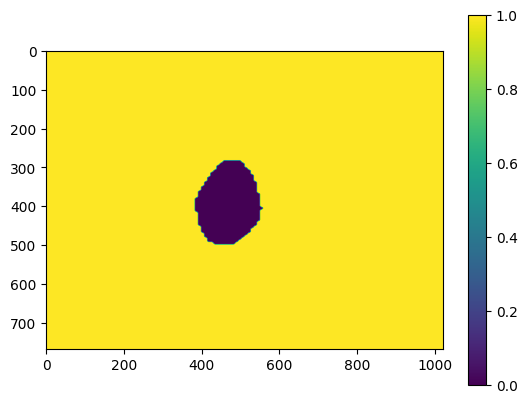

torch.Size([1, 1, 767, 1022])


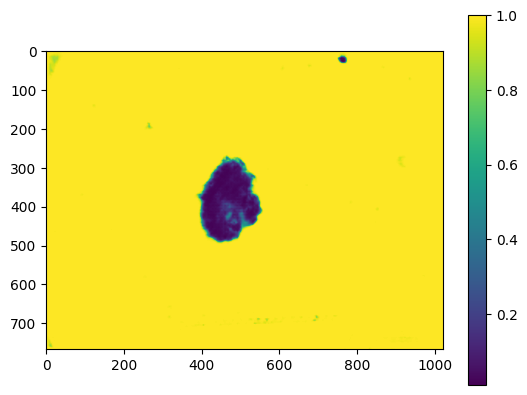

In [98]:
sg_model = model = UNET_2D(encoder)

checkpoint = torch.load( os.path.join(config["checkpoint"], "best.pt"))
sg_model.load_state_dict(checkpoint)

model = model.to(device)
data_iter = image_datasets['test']
inputs, mask = data_iter[1]
inputs = inputs.unsqueeze(0)
mask = 1 - mask.unsqueeze(0)
visualize_tensor(mask)
inputs = inputs.to(device) 
output = 1 - model(inputs)
print(output.size())
visualize_tensor(output)